In [1]:
from langgraph.graph import StateGraph, MessagesState, START, END

def mock_llm(state: MessagesState):
    return {"messages": [{"role": "ai", "content": "hello world"}]}

graph = StateGraph(MessagesState)
graph.add_node(mock_llm)
graph.add_edge(START, "mock_llm")
graph.add_edge("mock_llm", END)
graph = graph.compile()

graph.invoke({"messages": [{"role": "user", "content": "hi!"}]})

{'messages': [HumanMessage(content='hi!', additional_kwargs={}, response_metadata={}, id='be5e5fe3-7c43-4c01-abee-c42eb1aaf81f'),
  AIMessage(content='hello world', additional_kwargs={}, response_metadata={}, id='85f8c329-d677-493a-af84-1c7728e62e2f', tool_calls=[], invalid_tool_calls=[])]}

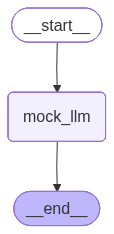

In [3]:
graph

In [8]:
import os
from langchain_aws import BedrockLLM
from langchain_aws import ChatBedrockConverse
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda,RunnableBranch
# ---------------------------
# AWS Bedrock LLM Setup
# ---------------------------
llm = ChatBedrockConverse(model_id="amazon.nova-lite-v1:0", region_name="us-east-1", temperature=0.5, max_tokens=50)


In [9]:
from langchain_core.prompts import ChatPromptTemplate
plan_prompt = ChatPromptTemplate.from_template("""
You are a project planner AI.
Break down the task into clear steps (1-5) with actionable goals.
Task: {task}
""")
planner = plan_prompt | llm | StrOutputParser()
def executor(plan_text):
    print("Executing tasks:\n")
    os.makedirs("website_launch", exist_ok=True)
    steps = [s.strip() for s in plan_text.split("\n") if s.strip()]
    for i, step in enumerate(steps, start=1):
        with open(f"website_launch/step_{i}.txt", "w") as f:
            f.write(step)
        print(f" {step}")
    print("\nAll tasks recorded in 'website_launch/' folder.")
task = "Plan my personal website launch"
plan_text = planner.invoke({"task": task})
print("Generated Plan:\n", plan_text)
executor(plan_text)


Generated Plan:
 Certainly! Here's a breakdown of the task "Plan my personal website launch" into clear steps with actionable goals:

### Step 1: Define Your Goals and Audience
**Actionable Goals:**
1. **Identify Purpose**: Determine the main
Executing tasks:

 Certainly! Here's a breakdown of the task "Plan my personal website launch" into clear steps with actionable goals:
 ### Step 1: Define Your Goals and Audience
 **Actionable Goals:**
 1. **Identify Purpose**: Determine the main

All tasks recorded in 'website_launch/' folder.
